# Notebook 05 — Temporal and Statistical Analysis of Chiang Mai Sounding Diagnostics

**รายวิชา:** บรรยากาศและคุณภาพอากาศ / Atmosphere and Air Quality  
**ระดับ:** นิสิตสิ่งแวดล้อม ปี 3–4  
**สถานี:** Chiang Mai — WMO **48327**  
**ช่วงข้อมูล:** 1 มีนาคม–30 เมษายน 2024  
**เวลา:** **00 UTC = 07:00 ICT**  
**จำนวนวัน:** 61 soundings

---

## ความต่อเนื่องของชุดการสอน

- Notebook 01 — ดาวน์โหลดและเตรียมข้อมูลจาก GitHub
- Notebook 02 — ทำความเข้าใจ sounding และ QC
- Notebook 03 — Skew‑T และ thermodynamic diagnostics
- Notebook 04 — stability, inversion และ air-pollution meteorology
- **Notebook 05 — temporal and statistical analysis**

Notebook นี้จะรวมผลจาก

```text
03_daily_thermodynamic_diagnostics_48327_00UTC_MarApr2024.csv
```

และ

```text
04_daily_airpollution_meteorology_48327_00UTC_MarApr2024.csv
```

ให้เป็น **daily analysis table** หนึ่งแถวต่อหนึ่งวัน

---

# วัตถุประสงค์การเรียนรู้

เมื่อจบ Notebook นี้ นิสิตควรสามารถ:

1. รวม derived datasets จากกระบวนการวิเคราะห์หลายขั้น
2. อธิบาย descriptive statistics ได้แก่ mean, median, SD, IQR และ percentiles
3. อธิบายเหตุผลที่ atmospheric variables บางชนิดควรใช้ median/IQR
4. วิเคราะห์ temporal variability และ rolling mean
5. เปรียบเทียบ March กับ April ด้วยกราฟและสถิติ
6. ใช้ Welch's t-test และ Mann–Whitney U test อย่างเหมาะสม
7. อธิบาย statistical significance และ effect size เบื้องต้น
8. คำนวณ Spearman rank correlation
9. สร้าง correlation matrix โดยไม่ใช้ correlation เป็นหลักฐานของ causation
10. ตรวจ temporal autocorrelation
11. อธิบายว่าทำไม daily observations อาจไม่เป็น independent samples อย่างสมบูรณ์
12. เตรียม daily diagnostic dataset สำหรับนำ PM₂.₅ มาวิเคราะห์ร่วมในงานต่อยอด

> **หลักสำคัญ:** สถิติช่วยสรุปและทดสอบรูปแบบในข้อมูล แต่ไม่สามารถแทน physical reasoning ได้

# 5.1 สถิติที่ใช้ใน Notebook นี้

## Mean

\[
\bar{x}=\frac{1}{n}\sum_{i=1}^{n}x_i
\]

เหมาะกับข้อมูลที่ distribution ไม่เบ้มากและไม่มี extreme values รุนแรง

## Median

ค่ากลางเมื่อเรียงข้อมูลจากน้อยไปมาก

Median ทนต่อ extreme values มากกว่า mean

## Standard deviation

\[
s=
\sqrt{
\frac{\sum(x_i-\bar{x})^2}{n-1}
}
\]

แสดงการกระจายรอบ mean

## Interquartile Range — IQR

\[
IQR=Q_{75}-Q_{25}
\]

แสดงการกระจายของข้อมูล 50% ตรงกลาง และทนต่อ outliers

## Percentiles

Notebook นี้ใช้:

- P10
- P25
- P50
- P75
- P90

เพื่อมอง distribution โดยไม่สมมติว่าข้อมูลเป็น normal distribution

In [1]:
# CELL 1 — Mount Google Drive
from google.colab import drive

drive.mount(
    "/content/drive",
    force_remount=False
)

Mounted at /content/drive


In [2]:
# CELL 2 — Imports and paths
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning
)

BASE_DIR = Path(
    "/content/drive/MyDrive/Teaching_Sounding_AirQuality"
)

OUTPUT_DIR = BASE_DIR / "03_output"
FIG_DIR = BASE_DIR / "04_figures"

THERMO_FILE = (
    OUTPUT_DIR
    / "03_daily_thermodynamic_diagnostics_48327_00UTC_MarApr2024.csv"
)

AIR_MET_FILE = (
    OUTPUT_DIR
    / "04_daily_airpollution_meteorology_48327_00UTC_MarApr2024.csv"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Expected inputs:")
print("1.", THERMO_FILE)
print("2.", AIR_MET_FILE)

Expected inputs:
1. /content/drive/MyDrive/Teaching_Sounding_AirQuality/03_output/03_daily_thermodynamic_diagnostics_48327_00UTC_MarApr2024.csv
2. /content/drive/MyDrive/Teaching_Sounding_AirQuality/03_output/04_daily_airpollution_meteorology_48327_00UTC_MarApr2024.csv


# 5.2 ตรวจ Input Files

Notebook นี้ตั้งใจให้ **independent from previous runtime**

ดังนั้นจะอ่าน CSV ที่ Notebook 03 และ 04 บันทึกไว้ ไม่ใช้ตัวแปรที่ค้างอยู่ใน memory

ถ้าไม่พบไฟล์ใดไฟล์หนึ่ง ให้กลับไปรัน notebook ที่เกี่ยวข้องก่อน

In [3]:
# CELL 3 — Validate input files
missing_files = [
    str(path)
    for path in [
        THERMO_FILE,
        AIR_MET_FILE
    ]
    if not path.exists()
]

if missing_files:

    message = (
        "Required derived files were not found.\n"
        "Please run Notebook 03 and Notebook 04 first.\n\n"
        + "\n".join(missing_files)
    )

    raise FileNotFoundError(
        message
    )

print("Input files found: OK")

Input files found: OK


In [4]:
# CELL 4 — Read and inspect both derived datasets
thermo = pd.read_csv(
    THERMO_FILE
)

airmet = pd.read_csv(
    AIR_MET_FILE
)

for table in [
    thermo,
    airmet
]:

    table["date"] = pd.to_datetime(
        table["date"],
        errors="coerce"
    )

    if "launch_datetime_utc" in table.columns:

        table["launch_datetime_utc"] = pd.to_datetime(
            table["launch_datetime_utc"],
            errors="coerce"
        )

print("Thermodynamic diagnostics:")
print(
    thermo.shape
)

display(
    thermo.head()
)

print("\nAir-pollution meteorology diagnostics:")
print(
    airmet.shape
)

display(
    airmet.head()
)

Thermodynamic diagnostics:
(61, 14)


,n_thermo_levels,status,LCL_pressure_hPa,LFC_pressure_hPa,EL_pressure_hPa,SBCAPE_Jkg,SBCIN_Jkg,MLCAPE_Jkg,MLCIN_Jkg,MUCAPE_Jkg,MUCIN_Jkg,PWAT_mm,launch_datetime_utc,date
0,46,ok,985.271139,NaN,NaN,0.0,0.0,0.0,0.0,0.000000,0.0,24.580944,2024-03-01,2024-03-01
1,53,ok,950.746277,NaN,NaN,0.0,0.0,0.0,0.0,0.000000,0.0,24.944463,2024-03-02,2024-03-02
2,61,ok,928.615661,NaN,NaN,0.0,0.0,0.0,0.0,64.182534,0.0,29.905389,2024-03-03,2024-03-03
3,56,ok,932.701852,NaN,NaN,0.0,0.0,0.0,0.0,0.000000,0.0,26.460255,2024-03-04,2024-03-04
4,54,ok,942.442941,NaN,NaN,0.0,0.0,0.0,0.0,0.000000,0.0,26.023941,2024-03-05,2024-03-05



Air-pollution meteorology diagnostics:
(61, 31)


,status,surface_height_m_MSL,lapse_0_500_C_per_km,lapse_0_1000_C_per_km,lapse_1000_3000_C_per_km,theta_grad_0_500_K_per_km,theta_grad_0_1000_K_per_km,N2_mean_0_500_s-2,N2_mean_0_1000_s-2,n_significant_inversions_0_3km,...,wind_0_500_dir_deg,wind_0_1000_speed_ms,wind_0_1000_dir_deg,mixing_height_Ri_m_AGL,mean_wind_within_mixing_ms,ventilation_coefficient_m2s,launch_datetime_utc,date,month,has_significant_inversion
0,ok,314.0,-7.474804,-4.086343,6.642027,17.367352,14.054374,0.000562,0.000433,1,...,180.000000,0.000000,180.000000,NaN,NaN,NaN,2024-03-01,2024-03-01,3,True
1,ok,314.0,-4.357400,3.536972,3.086204,21.552091,8.701803,0.000913,0.000492,1,...,266.180727,1.026774,261.284679,100.0,1.127069,112.706854,2024-03-02,2024-03-02,3,True
2,ok,314.0,-1.158393,4.642677,4.106443,18.260371,7.576325,0.000816,0.000445,1,...,268.917026,2.681479,258.973499,100.0,1.419295,141.929464,2024-03-03,2024-03-03,3,True
3,ok,314.0,-3.863754,3.847388,3.325545,22.046842,8.246198,0.000855,0.000460,1,...,0.400255,1.453452,323.803318,100.0,1.420389,142.038926,2024-03-04,2024-03-04,3,True
4,ok,314.0,-4.938163,4.039599,3.326246,22.842152,8.752981,0.000934,0.000502,1,...,83.010981,0.249627,50.521488,100.0,0.620671,62.067125,2024-03-05,2024-03-05,3,True


# 5.3 Merge Daily Diagnostics

ข้อมูลสองไฟล์เป็น derived products จาก sounding ชุดเดียวกัน

เราจะ merge โดยใช้ `date`

เป้าหมาย:

\[
1\ row = 1\ day
\]

และคาดหวัง:

\[
n=61
\]

โดย March = 31 วัน และ April = 30 วัน

In [5]:
# CELL 5 — Merge datasets carefully

# Drop duplicated administrative columns before merge.
thermo_merge = thermo.copy()
airmet_merge = airmet.copy()

# Keep status columns but rename them so their origin is clear.
if "status" in thermo_merge.columns:
    thermo_merge = thermo_merge.rename(
        columns={
            "status": "thermo_status"
        }
    )

if "status" in airmet_merge.columns:
    airmet_merge = airmet_merge.rename(
        columns={
            "status": "airmet_status"
        }
    )

# Avoid duplicate launch/month columns from the right table.
right_drop = [
    col
    for col in [
        "launch_datetime_utc",
        "month"
    ]
    if col in airmet_merge.columns
]

airmet_merge = airmet_merge.drop(
    columns=right_drop,
    errors="ignore"
)

daily = pd.merge(
    thermo_merge,
    airmet_merge,
    on="date",
    how="outer",
    validate="one_to_one"
)

daily = daily.sort_values(
    "date"
).reset_index(
    drop=True
)

daily["month_num"] = (
    daily["date"]
    .dt.month
)

daily["month_name"] = (
    daily["month_num"]
    .map({
        3: "March",
        4: "April"
    })
)

daily["day_of_study"] = np.arange(
    1,
    len(daily) + 1
)

print("Merged rows:", len(daily))
print(
    "First date:",
    daily["date"].min()
)

print(
    "Last date:",
    daily["date"].max()
)

print("\nMonth counts:")

display(
    daily["month_name"]
    .value_counts()
    .rename_axis("month")
    .reset_index(name="n")
)

display(
    daily.head()
)

Merged rows: 61
First date: 2024-03-01 00:00:00
Last date: 2024-04-30 00:00:00

Month counts:


,month,n
0,March,31
1,April,30


,n_thermo_levels,thermo_status,LCL_pressure_hPa,LFC_pressure_hPa,EL_pressure_hPa,SBCAPE_Jkg,SBCIN_Jkg,MLCAPE_Jkg,MLCIN_Jkg,MUCAPE_Jkg,...,wind_0_500_dir_deg,wind_0_1000_speed_ms,wind_0_1000_dir_deg,mixing_height_Ri_m_AGL,mean_wind_within_mixing_ms,ventilation_coefficient_m2s,has_significant_inversion,month_num,month_name,day_of_study
0,46,ok,985.271139,NaN,NaN,0.0,0.0,0.0,0.0,0.000000,...,180.000000,0.000000,180.000000,NaN,NaN,NaN,True,3,March,1
1,53,ok,950.746277,NaN,NaN,0.0,0.0,0.0,0.0,0.000000,...,266.180727,1.026774,261.284679,100.0,1.127069,112.706854,True,3,March,2
2,61,ok,928.615661,NaN,NaN,0.0,0.0,0.0,0.0,64.182534,...,268.917026,2.681479,258.973499,100.0,1.419295,141.929464,True,3,March,3
3,56,ok,932.701852,NaN,NaN,0.0,0.0,0.0,0.0,0.000000,...,0.400255,1.453452,323.803318,100.0,1.420389,142.038926,True,3,March,4
4,54,ok,942.442941,NaN,NaN,0.0,0.0,0.0,0.0,0.000000,...,83.010981,0.249627,50.521488,100.0,0.620671,62.067125,True,3,March,5


In [6]:
# CELL 6 — Core validation of merged daily table
expected_dates = pd.date_range(
    "2024-03-01",
    "2024-04-30",
    freq="D"
)

observed_dates = pd.DatetimeIndex(
    daily["date"].dropna()
)

missing_dates = expected_dates.difference(
    observed_dates
)

duplicate_dates = (
    daily["date"]
    .duplicated()
    .sum()
)

validation = pd.DataFrame([
    {
        "check": "Total daily rows",
        "observed": len(daily),
        "expected": 61,
        "status": "PASS" if len(daily) == 61 else "CHECK"
    },
    {
        "check": "March rows",
        "observed": int((daily["month_num"] == 3).sum()),
        "expected": 31,
        "status": "PASS" if int((daily["month_num"] == 3).sum()) == 31 else "CHECK"
    },
    {
        "check": "April rows",
        "observed": int((daily["month_num"] == 4).sum()),
        "expected": 30,
        "status": "PASS" if int((daily["month_num"] == 4).sum()) == 30 else "CHECK"
    },
    {
        "check": "Duplicate dates",
        "observed": int(duplicate_dates),
        "expected": 0,
        "status": "PASS" if duplicate_dates == 0 else "CHECK"
    },
    {
        "check": "Missing calendar dates",
        "observed": len(missing_dates),
        "expected": 0,
        "status": "PASS" if len(missing_dates) == 0 else "CHECK"
    }
])

print("=== MERGED DATA VALIDATION ===")

display(
    validation
)

if len(missing_dates) > 0:
    print(
        "\nMissing dates:"
    )
    print(
        missing_dates.tolist()
    )

=== MERGED DATA VALIDATION ===


,check,observed,expected,status
0,Total daily rows,61,61,PASS
1,March rows,31,31,PASS
2,April rows,30,30,PASS
3,Duplicate dates,0,0,PASS
4,Missing calendar dates,0,0,PASS


# 5.4 เลือกตัวแปรสำหรับการเรียนสถิติ

เพื่อไม่ให้ตารางใหญ่เกินไป จะเลือกตัวแปรตัวแทนจาก 3 กลุ่ม

## Thermodynamic environment

- SBCAPE
- SBCIN
- MLCAPE
- PWAT

## Atmospheric stability / inversion

- 0–500 m lapse rate
- 0–500 m potential-temperature gradient
- mean \(N^2\)
- lowest inversion strength

## Mixing / ventilation

- 0–500 m wind speed
- morning mixing-height diagnostic
- ventilation coefficient

ตัวแปรสามารถเพิ่มหรือลดได้ภายหลังตามโจทย์วิจัย

In [7]:
# CELL 7 — Select analysis variables and labels
VARIABLE_LABELS = {
    "SBCAPE_Jkg": "SBCAPE (J kg⁻¹)",
    "SBCIN_Jkg": "SBCIN (J kg⁻¹)",
    "MLCAPE_Jkg": "MLCAPE (J kg⁻¹)",
    "PWAT_mm": "PWAT (mm)",
    "lapse_0_500_C_per_km": "0–500 m lapse rate (°C km⁻¹)",
    "theta_grad_0_500_K_per_km": "0–500 m dθ/dz (K km⁻¹)",
    "N2_mean_0_500_s-2": "Mean N² 0–500 m (s⁻²)",
    "lowest_inv_strength_C_per_km": "Lowest inversion strength (°C km⁻¹)",
    "wind_0_500_speed_ms": "0–500 m wind speed (m s⁻¹)",
    "mixing_height_Ri_m_AGL": "Ri mixing-height diagnostic (m AGL)",
    "ventilation_coefficient_m2s": "Ventilation coefficient (m² s⁻¹)"
}

ANALYSIS_VARS = [
    col
    for col in VARIABLE_LABELS
    if col in daily.columns
]

print(
    "Variables available for statistical analysis:",
    len(ANALYSIS_VARS)
)

display(
    pd.DataFrame({
        "variable": ANALYSIS_VARS,
        "label": [
            VARIABLE_LABELS[v]
            for v in ANALYSIS_VARS
        ],
        "missing_n": [
            daily[v].isna().sum()
            for v in ANALYSIS_VARS
        ]
    })
)

Variables available for statistical analysis: 11


,variable,label,missing_n
0,SBCAPE_Jkg,SBCAPE (J kg⁻¹),0
1,SBCIN_Jkg,SBCIN (J kg⁻¹),0
2,MLCAPE_Jkg,MLCAPE (J kg⁻¹),0
3,PWAT_mm,PWAT (mm),0
4,lapse_0_500_C_per_km,0–500 m lapse rate (°C km⁻¹),0
5,theta_grad_0_500_K_per_km,0–500 m dθ/dz (K km⁻¹),0
6,N2_mean_0_500_s-2,Mean N² 0–500 m (s⁻²),0
7,lowest_inv_strength_C_per_km,Lowest inversion strength (°C km⁻¹),11
8,wind_0_500_speed_ms,0–500 m wind speed (m s⁻¹),0
9,mixing_height_Ri_m_AGL,Ri mixing-height diagnostic (m AGL),1


# 5.5 Descriptive Statistics

สำหรับแต่ละตัวแปรจะคำนวณ:

- count
- mean
- standard deviation
- minimum
- P10
- P25
- median (P50)
- P75
- P90
- maximum
- IQR
- skewness

### ทำไมต้องดู skewness?

ข้อมูลอย่าง CAPE และ ventilation coefficient อาจมี distribution ที่เบ้

ถ้า distribution เบ้มาก:

\[
mean \neq median
\]

ดังนั้น median และ IQR มักให้ภาพของค่ากลางและการกระจายที่ robust กว่า

In [8]:
# CELL 8 — Descriptive-statistics function
def descriptive_summary(
    data,
    variables
):
    rows = []

    for var in variables:

        x = pd.to_numeric(
            data[var],
            errors="coerce"
        ).dropna()

        if len(x) == 0:
            continue

        q10, q25, q50, q75, q90 = np.percentile(
            x,
            [
                10,
                25,
                50,
                75,
                90
            ]
        )

        rows.append({
            "variable": var,
            "label": VARIABLE_LABELS.get(var, var),
            "n": len(x),
            "mean": x.mean(),
            "sd": x.std(ddof=1),
            "min": x.min(),
            "P10": q10,
            "P25": q25,
            "median_P50": q50,
            "P75": q75,
            "P90": q90,
            "max": x.max(),
            "IQR": q75 - q25,
            "skewness": stats.skew(
                x,
                bias=False
            ) if len(x) >= 3 else np.nan
        })

    return pd.DataFrame(
        rows
    )


descriptive_all = descriptive_summary(
    daily,
    ANALYSIS_VARS
)

print(
    "=== DESCRIPTIVE STATISTICS: ALL 61 DAYS ==="
)

display(
    descriptive_all
)

=== DESCRIPTIVE STATISTICS: ALL 61 DAYS ===


,variable,label,n,mean,sd,min,P10,P25,median_P50,P75,P90,max,IQR,skewness
0,SBCAPE_Jkg,SBCAPE (J kg⁻¹),61,693.546391,912.293770,-139.808446,0.000000,0.000000,214.069572,1179.034470,1760.357998,4007.453847,1179.034470,1.623473
1,SBCIN_Jkg,SBCIN (J kg⁻¹),61,-184.942535,175.310223,-578.257897,-434.554203,-308.166083,-169.113610,0.000000,0.000000,0.000000,308.166083,-0.405308
2,MLCAPE_Jkg,MLCAPE (J kg⁻¹),61,107.276333,257.077947,-165.114837,0.000000,0.000000,0.000000,86.475118,401.687106,1312.984944,86.475118,3.013711
3,PWAT_mm,PWAT (mm),61,29.525822,6.801859,17.298896,19.850210,24.115000,30.958441,35.391091,37.118062,42.480807,11.276091,-0.161901
4,lapse_0_500_C_per_km,0–500 m lapse rate (°C km⁻¹),61,-3.119762,5.025214,-26.813024,-7.522184,-5.904386,-2.794975,0.083683,3.074812,4.703189,5.988068,-1.687572
5,theta_grad_0_500_K_per_km,0–500 m dθ/dz (K km⁻¹),61,13.494121,5.483789,5.060284,6.608364,9.866485,12.833150,16.162265,20.502698,36.646933,6.295780,1.258457
6,N2_mean_0_500_s-2,Mean N² 0–500 m (s⁻²),61,0.000449,0.000170,0.000179,0.000248,0.000317,0.000442,0.000528,0.000632,0.000934,0.000211,0.864568
7,lowest_inv_strength_C_per_km,Lowest inversion strength (°C km⁻¹),50,12.098363,6.641816,3.000000,4.413121,6.818649,11.315642,15.515518,21.987622,31.723046,8.696870,0.866686
8,wind_0_500_speed_ms,0–500 m wind speed (m s⁻¹),61,2.557588,1.744904,0.000000,0.675911,1.570411,2.336641,3.246967,4.460773,9.760282,1.676556,1.646780
9,mixing_height_Ri_m_AGL,Ri mixing-height diagnostic (m AGL),60,127.500000,51.605577,100.000000,100.000000,100.000000,100.000000,150.000000,200.000000,300.000000,50.000000,2.062245


# 5.6 March vs April — Descriptive Comparison

ก่อนทำ hypothesis test ควรดู descriptive statistics ของแต่ละเดือนก่อน

การเปรียบเทียบจะรายงานทั้ง:

- mean ± SD
- median
- IQR
- n

เนื่องจาก March มี 31 วัน และ April มี 30 วัน จึงมี sample size ใกล้เคียงกันมาก

In [9]:
# CELL 9 — Monthly descriptive summary
monthly_rows = []

for month_name in [
    "March",
    "April"
]:

    subset = daily[
        daily["month_name"]
        == month_name
    ]

    summary = descriptive_summary(
        subset,
        ANALYSIS_VARS
    )

    summary.insert(
        0,
        "month",
        month_name
    )

    monthly_rows.append(
        summary
    )


descriptive_monthly = pd.concat(
    monthly_rows,
    ignore_index=True
)

display(
    descriptive_monthly
)

,month,variable,label,n,mean,sd,min,P10,P25,median_P50,P75,P90,max,IQR,skewness
0,March,SBCAPE_Jkg,SBCAPE (J kg⁻¹),31,105.723733,321.997181,-139.808446,0.000000,0.000000,0.000000,7.018054,148.250809,1207.666570,7.018054,2.904279
1,March,SBCIN_Jkg,SBCIN (J kg⁻¹),31,-128.921220,203.577566,-578.257897,-450.713738,-340.873370,0.000000,0.000000,0.000000,0.000000,340.873370,-1.098116
2,March,MLCAPE_Jkg,MLCAPE (J kg⁻¹),31,5.978466,21.794893,0.000000,0.000000,0.000000,0.000000,0.000000,2.549994,88.381297,0.000000,3.700996
3,March,PWAT_mm,PWAT (mm),31,24.709423,5.311128,17.298896,18.328930,20.638107,24.580944,27.017195,32.133724,36.390847,6.379089,0.650317
4,March,lapse_0_500_C_per_km,0–500 m lapse rate (°C km⁻¹),31,-5.701493,5.424594,-26.813024,-10.389487,-7.331365,-5.681166,-3.754884,-1.158393,4.486670,3.576481,-1.652420
5,March,theta_grad_0_500_K_per_km,0–500 m dθ/dz (K km⁻¹),31,16.626479,5.676775,5.432766,11.543538,13.988077,16.162265,19.034449,21.695634,36.646933,5.046372,1.019036
6,March,N2_mean_0_500_s-2,Mean N² 0–500 m (s⁻²),31,0.000544,0.000178,0.000179,0.000393,0.000468,0.000528,0.000596,0.000816,0.000934,0.000128,0.236698
7,March,lowest_inv_strength_C_per_km,Lowest inversion strength (°C km⁻¹),29,14.747693,6.633945,4.735417,7.328158,11.314827,13.376147,17.000000,23.717925,31.723046,5.685173,0.798846
8,March,wind_0_500_speed_ms,0–500 m wind speed (m s⁻¹),31,2.271770,1.548570,0.000000,0.490466,1.159838,2.247209,2.746612,3.535029,7.605962,1.586775,1.338178
9,March,mixing_height_Ri_m_AGL,Ri mixing-height diagnostic (m AGL),30,116.666667,46.113304,100.000000,100.000000,100.000000,100.000000,100.000000,150.000000,300.000000,0.000000,3.213086


# 5.7 Time Series

Time series ช่วยให้เห็น:

- day-to-day variability
- unusual days
- transition จาก March ไป April
- persistence หลายวันต่อเนื่อง

แต่ raw daily values อาจผันผวนมาก จึงใช้ rolling mean ช่วยแสดง low-frequency variation

In [10]:
# CELL 10 — Choose variables for time-series teaching plots
TIME_SERIES_VARS = [
    var
    for var in [
        "PWAT_mm",
        "SBCAPE_Jkg",
        "theta_grad_0_500_K_per_km",
        "mixing_height_Ri_m_AGL",
        "ventilation_coefficient_m2s"
    ]
    if var in daily.columns
]

print(
    TIME_SERIES_VARS
)

['PWAT_mm', 'SBCAPE_Jkg', 'theta_grad_0_500_K_per_km', 'mixing_height_Ri_m_AGL', 'ventilation_coefficient_m2s']


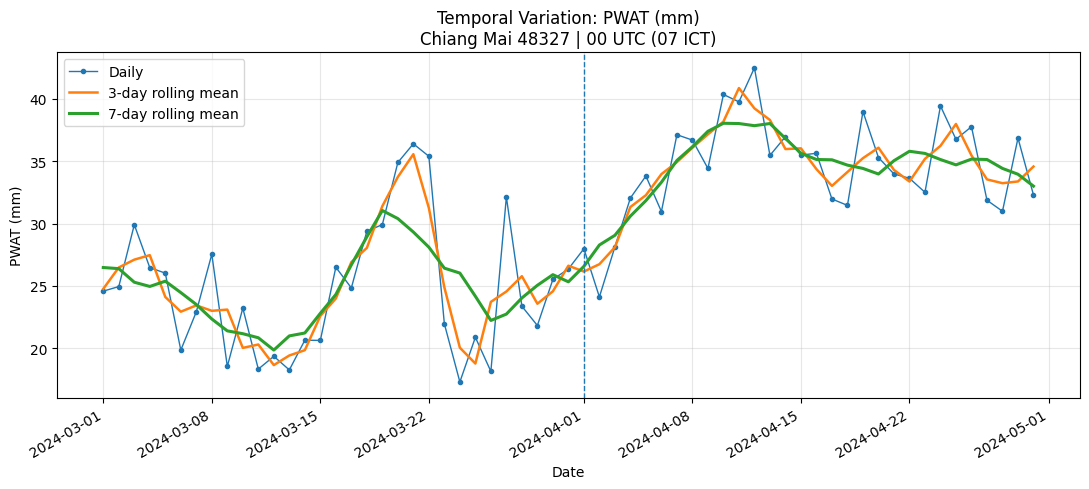

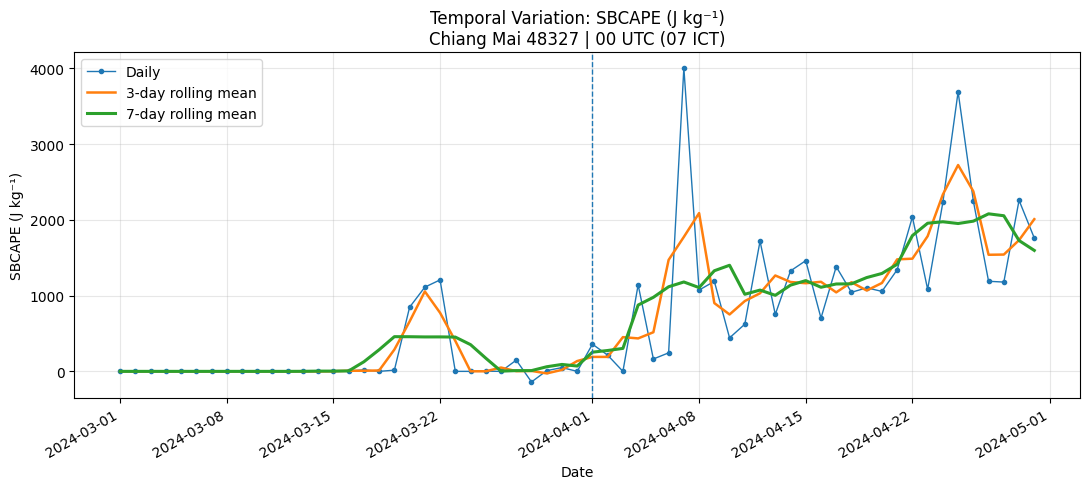

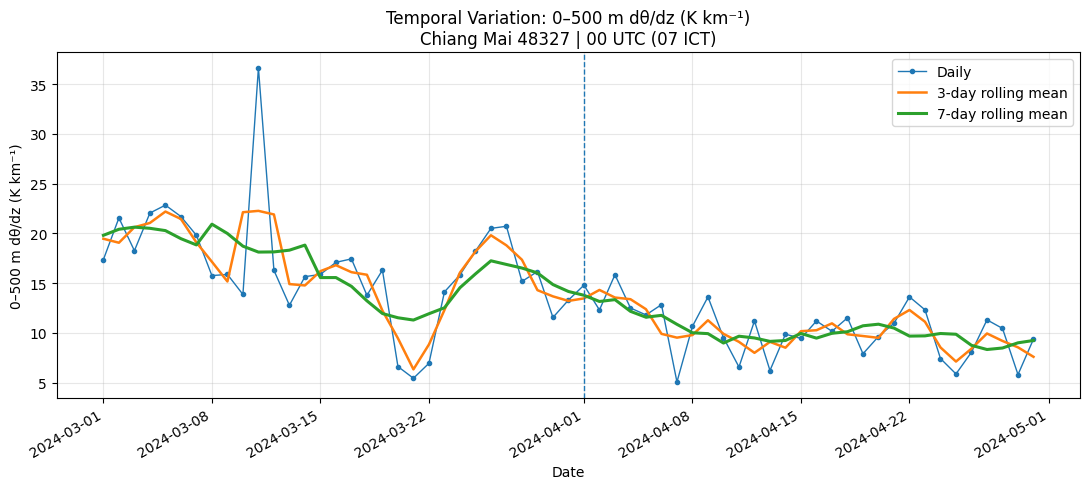

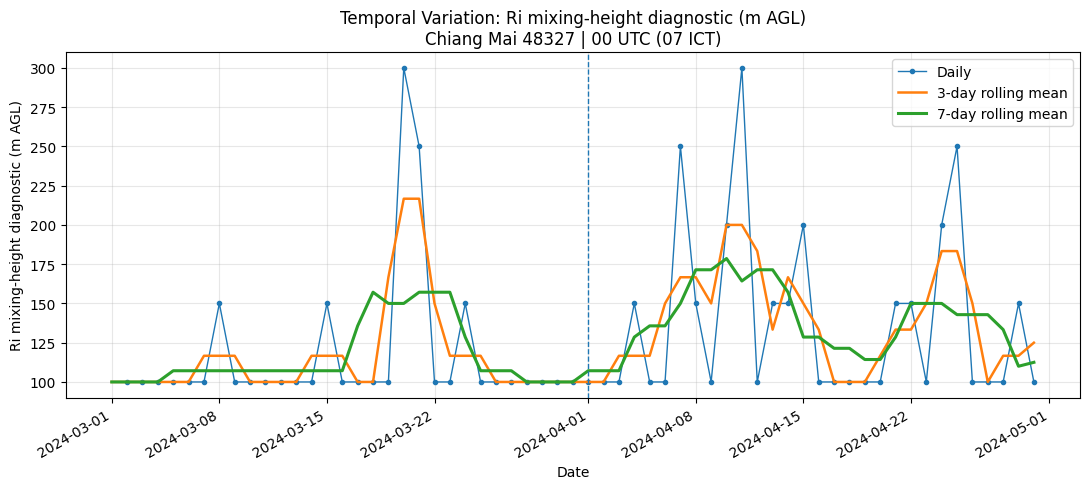

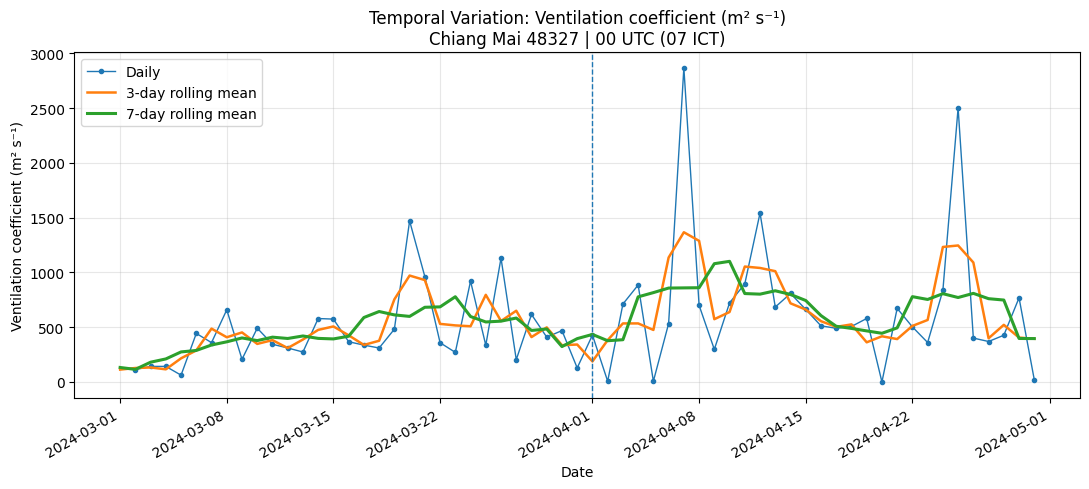

In [11]:
# CELL 11 — Time series + 3-day and 7-day rolling means
for var in TIME_SERIES_VARS:

    x = daily[
        [
            "date",
            var
        ]
    ].copy()

    x[var] = pd.to_numeric(
        x[var],
        errors="coerce"
    )

    x["rolling_3d"] = (
        x[var]
        .rolling(
            window=3,
            center=True,
            min_periods=1
        )
        .mean()
    )

    x["rolling_7d"] = (
        x[var]
        .rolling(
            window=7,
            center=True,
            min_periods=1
        )
        .mean()
    )

    fig, ax = plt.subplots(
        figsize=(11, 5)
    )

    ax.plot(
        x["date"],
        x[var],
        marker="o",
        markersize=3,
        linewidth=1,
        label="Daily"
    )

    ax.plot(
        x["date"],
        x["rolling_3d"],
        linewidth=1.8,
        label="3-day rolling mean"
    )

    ax.plot(
        x["date"],
        x["rolling_7d"],
        linewidth=2.2,
        label="7-day rolling mean"
    )

    ax.axvline(
        pd.Timestamp("2024-04-01"),
        linestyle="--",
        linewidth=1
    )

    ax.set_xlabel(
        "Date"
    )

    ax.set_ylabel(
        VARIABLE_LABELS.get(
            var,
            var
        )
    )

    ax.set_title(
        f"Temporal Variation: {VARIABLE_LABELS.get(var, var)}\n"
        "Chiang Mai 48327 | 00 UTC (07 ICT)"
    )

    ax.grid(
        alpha=0.3
    )

    ax.legend()

    fig.autofmt_xdate()
    fig.tight_layout()

    fig_path = (
        FIG_DIR
        / f"05_timeseries_{var}.png"
    )

    fig.savefig(
        fig_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

## Rolling mean ไม่ใช่ observation ใหม่

3-day และ 7-day rolling mean เป็น smoothing tool

ข้อดี:

- เห็น multi-day regime ชัดขึ้น
- ลด high-frequency fluctuation

ข้อจำกัด:

- ทำให้ extreme days ดูอ่อนลง
- neighboring values ถูกนำมาเฉลี่ยกัน
- ไม่ควรใช้ rolling mean แทน raw observations ใน hypothesis test โดยไม่อธิบายวิธีการ

# 5.8 Boxplot: March vs April

Boxplot แสดง:

- median
- interquartile range
- whiskers
- potential outliers

เหมาะสำหรับเปรียบเทียบ distribution ระหว่างสองเดือนโดยไม่ต้องสมมติ normal distribution

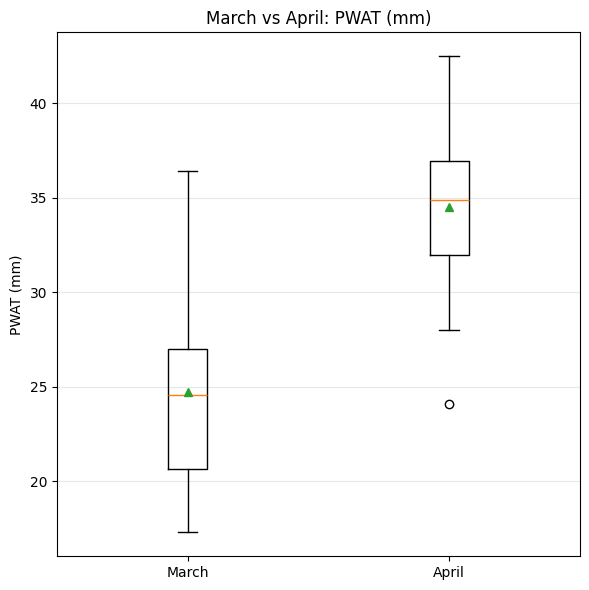

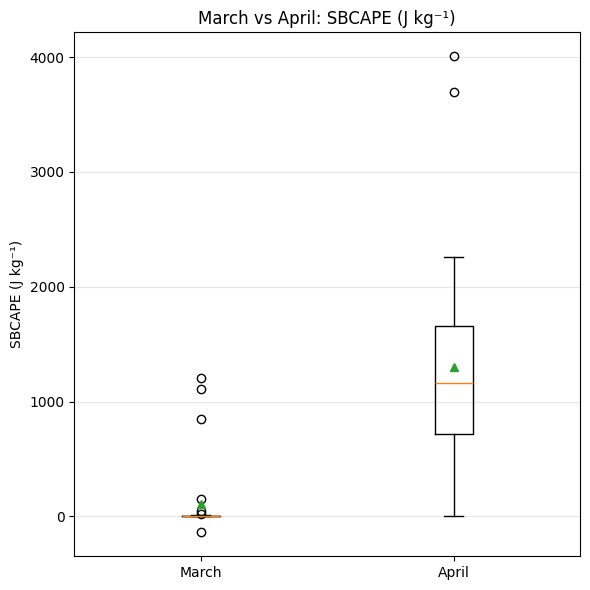

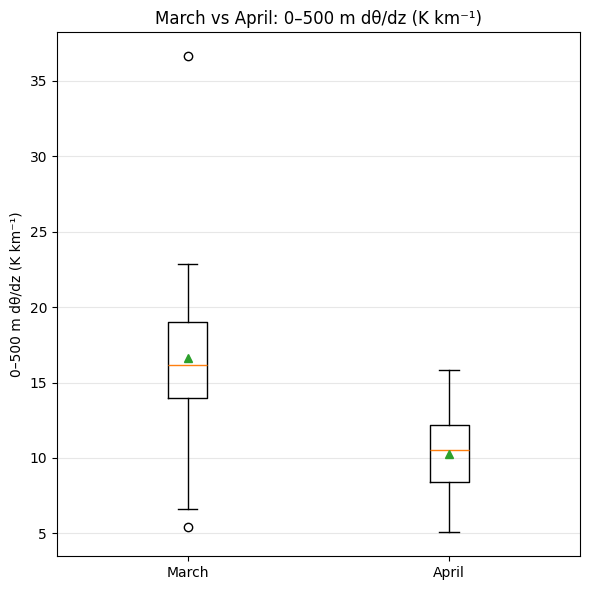

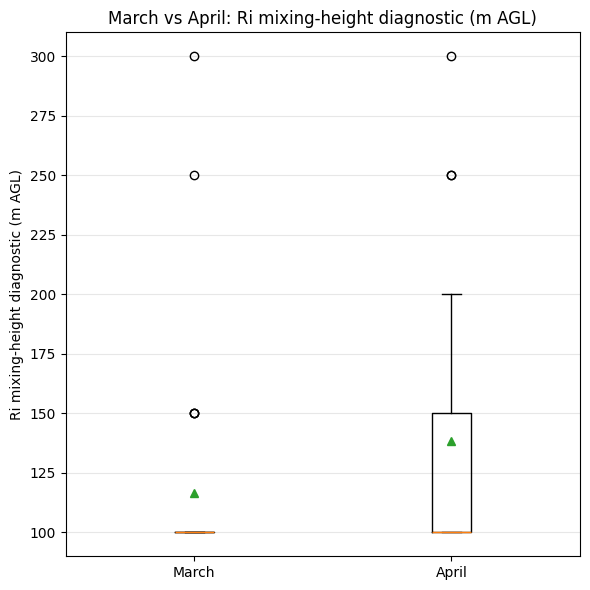

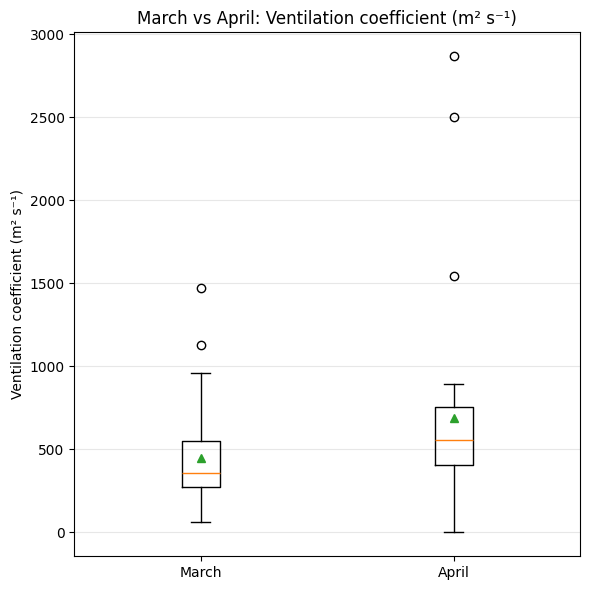

In [12]:
# CELL 12 — Boxplots
BOX_VARS = [
    var
    for var in [
        "PWAT_mm",
        "SBCAPE_Jkg",
        "theta_grad_0_500_K_per_km",
        "mixing_height_Ri_m_AGL",
        "ventilation_coefficient_m2s"
    ]
    if var in daily.columns
]

for var in BOX_VARS:

    march = pd.to_numeric(
        daily.loc[
            daily["month_name"] == "March",
            var
        ],
        errors="coerce"
    ).dropna()

    april = pd.to_numeric(
        daily.loc[
            daily["month_name"] == "April",
            var
        ],
        errors="coerce"
    ).dropna()

    fig, ax = plt.subplots(
        figsize=(6, 6)
    )

    ax.boxplot(
        [
            march,
            april
        ],
        tick_labels=[
            "March",
            "April"
        ],
        showmeans=True
    )

    ax.set_ylabel(
        VARIABLE_LABELS.get(
            var,
            var
        )
    )

    ax.set_title(
        f"March vs April: {VARIABLE_LABELS.get(var, var)}"
    )

    ax.grid(
        axis="y",
        alpha=0.3
    )

    fig.tight_layout()

    fig_path = (
        FIG_DIR
        / f"05_boxplot_March_April_{var}.png"
    )

    fig.savefig(
        fig_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

# 5.9 ECDF — Empirical Cumulative Distribution Function

ECDF แสดงสัดส่วนของ observations ที่มีค่าไม่เกิน \(x\)

\[
F_n(x)=
\frac{1}{n}
\sum_{i=1}^{n}
I(X_i\le x)
\]

ข้อดี:

- ไม่ต้องเลือก bin แบบ histogram
- เห็น distribution ทั้งช่วง
- เปรียบเทียบ March–April ได้ชัด

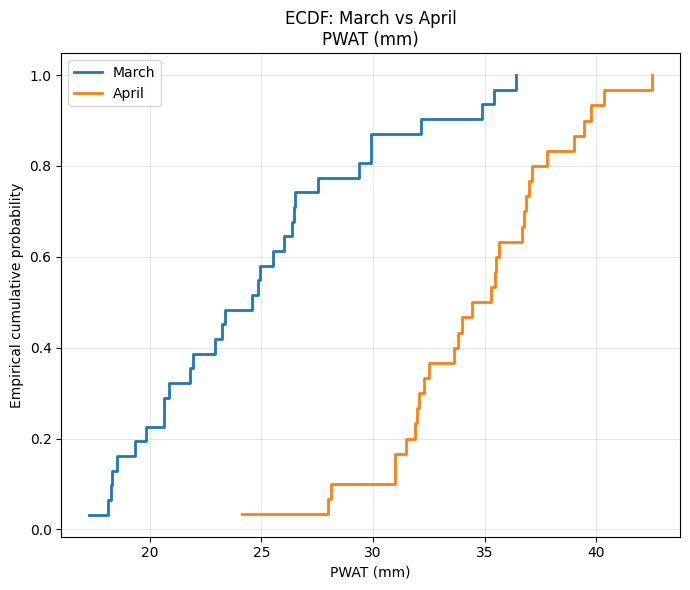

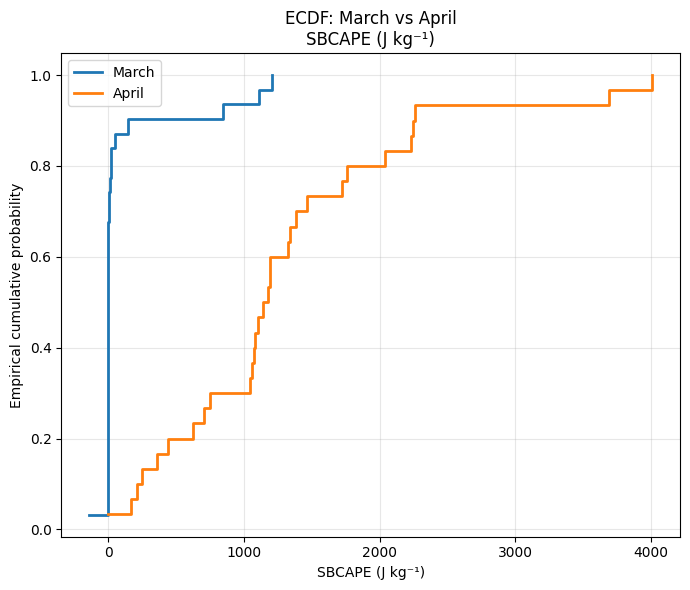

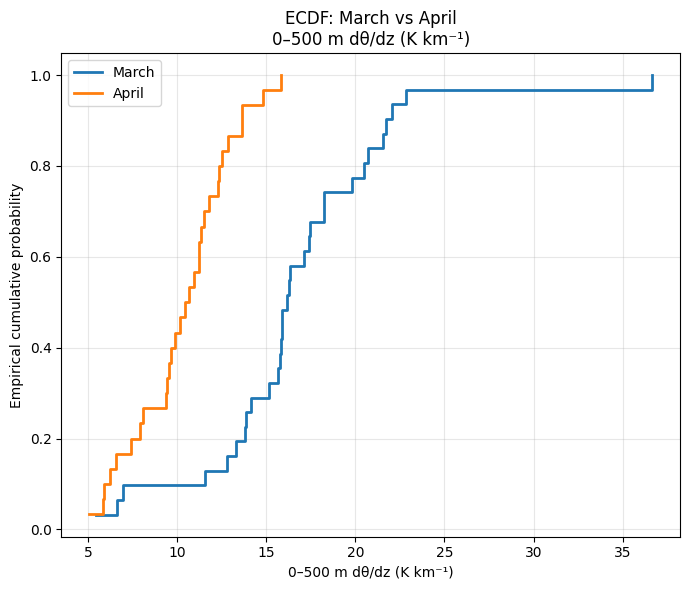

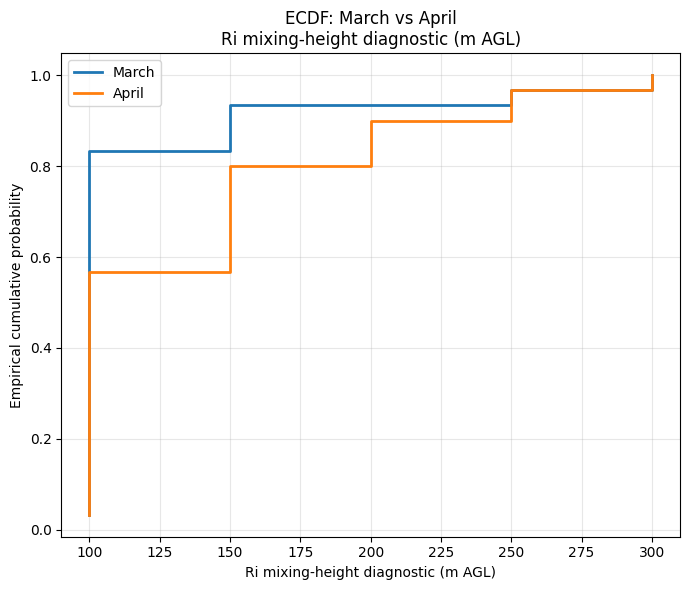

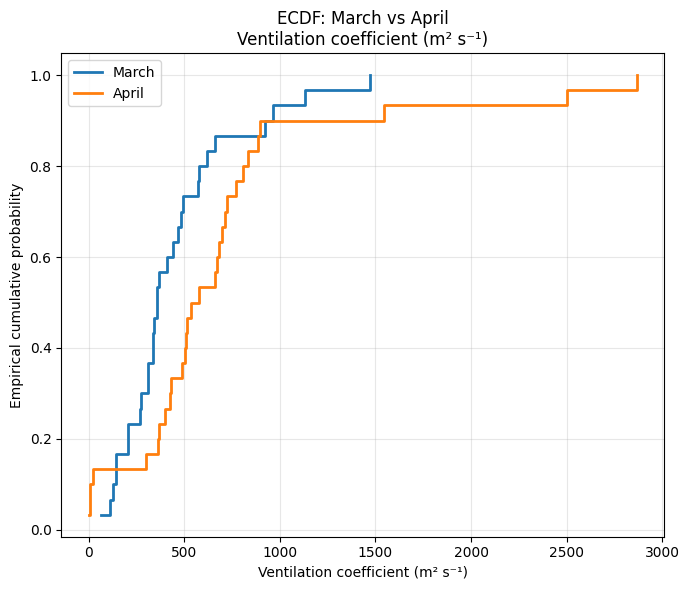

In [13]:
# CELL 13 — ECDF function and plots
def ecdf(
    values
):
    x = np.sort(
        np.asarray(
            values,
            dtype=float
        )
    )

    x = x[
        np.isfinite(x)
    ]

    n = len(x)

    if n == 0:
        return (
            np.array([]),
            np.array([])
        )

    y = (
        np.arange(
            1,
            n + 1
        )
        / n
    )

    return x, y


for var in BOX_VARS:

    fig, ax = plt.subplots(
        figsize=(7, 6)
    )

    for month_name in [
        "March",
        "April"
    ]:

        values = pd.to_numeric(
            daily.loc[
                daily["month_name"] == month_name,
                var
            ],
            errors="coerce"
        ).dropna()

        x, y = ecdf(
            values
        )

        ax.step(
            x,
            y,
            where="post",
            linewidth=2,
            label=month_name
        )

    ax.set_xlabel(
        VARIABLE_LABELS.get(
            var,
            var
        )
    )

    ax.set_ylabel(
        "Empirical cumulative probability"
    )

    ax.set_title(
        f"ECDF: March vs April\n{VARIABLE_LABELS.get(var, var)}"
    )

    ax.grid(
        alpha=0.3
    )

    ax.legend()

    fig.tight_layout()

    fig_path = (
        FIG_DIR
        / f"05_ECDF_March_April_{var}.png"
    )

    fig.savefig(
        fig_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

# 5.10 Hypothesis Testing

เราจะใช้ 2 วิธี

## Welch's t-test

ทดสอบความแตกต่างของ mean ระหว่าง 2 กลุ่ม โดยไม่บังคับให้ variance เท่ากัน

สมมติฐาน:

\[
H_0:\mu_{March}=\mu_{April}
\]

\[
H_1:\mu_{March}\neq\mu_{April}
\]

เหมาะเมื่อการเปรียบเทียบ mean มีความหมาย และ distribution ไม่รุนแรงจนทำให้ mean ไม่น่าเป็นตัวแทน

---

## Mann–Whitney U test

เป็น rank-based non-parametric test

ใช้ตรวจว่าการกระจายของสองกลุ่มมีแนวโน้มต่างกันหรือไม่ โดยไม่ต้องสมมติ normal distribution

ควรระวังการเรียกผล Mann–Whitney ว่า “ทดสอบ median” โดยตรง เพราะการตีความเป็น median difference ต้องอาศัย assumptions เพิ่มเติมเกี่ยวกับรูป distribution

## Statistical significance

กำหนดตัวอย่าง:

\[
\alpha=0.05
\]

ถ้า

\[
p<0.05
\]

เรากล่าวว่า “พบหลักฐานทางสถิติให้ปฏิเสธ \(H_0\) ที่ระดับ 0.05”

ไม่ควรแปลว่า:

- effect ใหญ่
- สำคัญทางกายภาพ
- มี causal relationship
- โอกาสที่ \(H_0\) เป็นจริงเท่ากับ 5%

ดังนั้นควรรายงาน **effect size** และ descriptive statistics ร่วมด้วย

In [14]:
# CELL 14 — Statistical-test helper functions
ALPHA = 0.05


def cohens_d_welch(
    x,
    y
):
    """
    Standardized mean difference using pooled
    sample variance for descriptive effect size.
    """
    x = np.asarray(
        x,
        dtype=float
    )

    y = np.asarray(
        y,
        dtype=float
    )

    x = x[
        np.isfinite(x)
    ]

    y = y[
        np.isfinite(y)
    ]

    if len(x) < 2 or len(y) < 2:
        return np.nan

    pooled_sd = np.sqrt(
        (
            (len(x) - 1)
            * np.var(
                x,
                ddof=1
            )
            +
            (len(y) - 1)
            * np.var(
                y,
                ddof=1
            )
        )
        /
        (
            len(x)
            + len(y)
            - 2
        )
    )

    if pooled_sd == 0:
        return np.nan

    return float(
        (
            np.mean(y)
            - np.mean(x)
        )
        / pooled_sd
    )


def rank_biserial_from_u(
    u,
    n1,
    n2
):
    if n1 == 0 or n2 == 0:
        return np.nan

    return float(
        2
        * u
        / (
            n1
            * n2
        )
        - 1
    )

In [15]:
# CELL 15 — March vs April hypothesis tests
test_rows = []

for var in ANALYSIS_VARS:

    march = pd.to_numeric(
        daily.loc[
            daily["month_name"] == "March",
            var
        ],
        errors="coerce"
    ).dropna().to_numpy()

    april = pd.to_numeric(
        daily.loc[
            daily["month_name"] == "April",
            var
        ],
        errors="coerce"
    ).dropna().to_numpy()

    if len(march) < 3 or len(april) < 3:
        continue

    welch = stats.ttest_ind(
        march,
        april,
        equal_var=False,
        nan_policy="omit"
    )

    mw = stats.mannwhitneyu(
        march,
        april,
        alternative="two-sided"
    )

    test_rows.append({
        "variable": var,
        "label": VARIABLE_LABELS.get(
            var,
            var
        ),
        "n_March": len(march),
        "n_April": len(april),
        "mean_March": np.mean(march),
        "mean_April": np.mean(april),
        "median_March": np.median(march),
        "median_April": np.median(april),
        "mean_difference_April_minus_March": (
            np.mean(april)
            - np.mean(march)
        ),
        "median_difference_April_minus_March": (
            np.median(april)
            - np.median(march)
        ),
        "Welch_t": float(welch.statistic),
        "Welch_p": float(welch.pvalue),
        "Welch_significant_0p05": (
            welch.pvalue < ALPHA
        ),
        "Cohens_d_April_minus_March": cohens_d_welch(
            march,
            april
        ),
        "MannWhitney_U": float(mw.statistic),
        "MannWhitney_p": float(mw.pvalue),
        "MW_significant_0p05": (
            mw.pvalue < ALPHA
        ),
        "rank_biserial_March_vs_April": rank_biserial_from_u(
            mw.statistic,
            len(march),
            len(april)
        )
    })


tests_month = pd.DataFrame(
    test_rows
)

print(
    "=== MARCH VS APRIL STATISTICAL TESTS ==="
)

display(
    tests_month
)

=== MARCH VS APRIL STATISTICAL TESTS ===


,variable,label,n_March,n_April,mean_March,mean_April,median_March,median_April,mean_difference_April_minus_March,median_difference_April_minus_March,Welch_t,Welch_p,Welch_significant_0p05,Cohens_d_April_minus_March,MannWhitney_U,MannWhitney_p,MW_significant_0p05,rank_biserial_March_vs_April
0,SBCAPE_Jkg,SBCAPE (J kg⁻¹),31,30,105.723733,1300.963138,0.000000,1160.592533,1195.239404,1160.592533,-6.667731,9.406665e-08,True,1.730180,58.5,2.478909e-09,True,-0.874194
1,SBCIN_Jkg,SBCIN (J kg⁻¹),31,30,-128.921220,-242.831227,0.000000,-225.298900,-113.910007,-225.298900,2.684899,9.908093e-03,True,-0.681941,670.5,2.605658e-03,True,0.441935
2,MLCAPE_Jkg,MLCAPE (J kg⁻¹),31,30,5.978466,211.950794,0.000000,38.034804,205.972328,38.034804,-3.335454,2.326701e-03,True,0.868483,244.0,5.261523e-04,True,-0.475269
3,PWAT_mm,PWAT (mm),31,30,24.709423,34.502768,24.580944,34.852632,9.793346,10.271687,-8.140702,4.669956e-11,True,2.075443,77.0,2.268475e-08,True,-0.834409
4,lapse_0_500_C_per_km,0–500 m lapse rate (°C km⁻¹),31,30,-5.701493,-0.451973,-5.681166,-0.882269,5.249520,4.798897,-4.805792,1.797710e-05,True,1.218521,128.0,1.207326e-06,True,-0.724731
5,theta_grad_0_500_K_per_km,0–500 m dθ/dz (K km⁻¹),31,30,16.626479,10.257351,16.162265,10.550119,-6.369128,-5.612146,5.604755,1.311686e-06,True,-1.420661,823.0,2.504258e-07,True,0.769892
6,N2_mean_0_500_s-2,Mean N² 0–500 m (s⁻²),31,30,0.000544,0.000351,0.000528,0.000332,-0.000193,-0.000196,5.418686,2.429254e-06,True,-1.373559,799.0,1.500623e-06,True,0.718280
7,lowest_inv_strength_C_per_km,Lowest inversion strength (°C km⁻¹),29,21,14.747693,8.439765,13.376147,7.759819,-6.307928,-5.616328,3.929961,2.719100e-04,True,-1.067210,483.0,4.673884e-04,True,0.586207
8,wind_0_500_speed_ms,0–500 m wind speed (m s⁻¹),31,30,2.271770,2.852932,2.247209,2.432501,0.581162,0.185292,-1.303681,1.976930e-01,False,0.335031,388.0,2.697633e-01,False,-0.165591
9,mixing_height_Ri_m_AGL,Ri mixing-height diagnostic (m AGL),30,30,116.666667,138.333333,100.000000,100.000000,21.666667,0.000000,-1.649626,1.045970e-01,False,0.425932,331.5,3.076465e-02,True,-0.263333


## การตีความ effect size เบื้องต้น

สำหรับ Cohen's \(d\) มักใช้เกณฑ์เชิง heuristic เช่น

- \(|d|\approx0.2\) small
- \(|d|\approx0.5\) medium
- \(|d|\approx0.8\) large

แต่เกณฑ์เหล่านี้ไม่ใช่กฎทางกายภาพ

ใน atmospheric science ควรพิจารณาว่า difference มี **meteorological meaning** หรือไม่ร่วมด้วย

เช่น difference 50 m ของ mixing height อาจมีความหมายต่างกันใน stable morning layer กับ deep daytime convective boundary layer

# 5.11 Multiple Testing

เมื่อทดสอบหลายตัวแปรพร้อมกัน โอกาสพบ \(p<0.05\) อย่างน้อยหนึ่งตัวจาก chance จะเพิ่มขึ้น

Notebook นี้จะแสดง **Benjamini–Hochberg False Discovery Rate (FDR)** เป็นตัวอย่างเพิ่มเติม

จุดประสงค์คือให้นิสิตเห็นว่า:

> การดู p-value หลายสิบค่าโดยไม่พิจารณา multiple testing อาจเพิ่ม false-positive findings

FDR ไม่จำเป็นต้องใช้ในทุกแบบฝึกหัด แต่ควรรู้แนวคิดก่อนทำงานวิจัยจริง

In [16]:
# CELL 16 — Benjamini-Hochberg FDR helper
def benjamini_hochberg(
    pvalues
):
    p = np.asarray(
        pvalues,
        dtype=float
    )

    adjusted = np.full(
        len(p),
        np.nan
    )

    valid = np.isfinite(
        p
    )

    pv = p[
        valid
    ]

    if len(pv) == 0:
        return adjusted

    order = np.argsort(
        pv
    )

    ranked = pv[
        order
    ]

    m = len(
        ranked
    )

    adj_ranked = (
        ranked
        * m
        / np.arange(
            1,
            m + 1
        )
    )

    adj_ranked = np.minimum.accumulate(
        adj_ranked[::-1]
    )[::-1]

    adj_ranked = np.clip(
        adj_ranked,
        0,
        1
    )

    back = np.empty(
        m
    )

    back[
        order
    ] = adj_ranked

    adjusted[
        valid
    ] = back

    return adjusted


if len(tests_month) > 0:

    tests_month[
        "Welch_p_FDR"
    ] = benjamini_hochberg(
        tests_month[
            "Welch_p"
        ]
    )

    tests_month[
        "MW_p_FDR"
    ] = benjamini_hochberg(
        tests_month[
            "MannWhitney_p"
        ]
    )

    tests_month[
        "Welch_FDR_significant_0p05"
    ] = (
        tests_month[
            "Welch_p_FDR"
        ]
        < ALPHA
    )

    tests_month[
        "MW_FDR_significant_0p05"
    ] = (
        tests_month[
            "MW_p_FDR"
        ]
        < ALPHA
    )

display(
    tests_month[
        [
            "variable",
            "Welch_p",
            "Welch_p_FDR",
            "MannWhitney_p",
            "MW_p_FDR"
        ]
    ]
)

,variable,Welch_p,Welch_p_FDR,MannWhitney_p,MW_p_FDR
0,SBCAPE_Jkg,9.406665e-08,5.173666e-07,2.478909e-09,2.726800e-08
1,SBCIN_Jkg,9.908093e-03,1.362363e-02,2.605658e-03,3.582780e-03
2,MLCAPE_Jkg,2.326701e-03,3.656245e-03,5.261523e-04,8.268108e-04
3,PWAT_mm,4.669956e-11,5.136952e-10,2.268475e-08,1.247661e-07
4,lapse_0_500_C_per_km,1.797710e-05,3.954962e-05,1.207326e-06,3.301371e-06
5,theta_grad_0_500_K_per_km,1.311686e-06,4.809514e-06,2.504258e-07,9.182278e-07
6,N2_mean_0_500_s-2,2.429254e-06,6.680449e-06,1.500623e-06,3.301371e-06
7,lowest_inv_strength_C_per_km,2.719100e-04,4.985016e-04,4.673884e-04,8.268108e-04
8,wind_0_500_speed_ms,1.976930e-01,1.976930e-01,2.697633e-01,2.697633e-01
9,mixing_height_Ri_m_AGL,1.045970e-01,1.150568e-01,3.076465e-02,3.384112e-02


# 5.12 Spearman Rank Correlation

Spearman correlation ใช้ rank ของข้อมูล

\[
\rho_s
=
corr(rank(X),rank(Y))
\]

เหมาะสำหรับความสัมพันธ์แบบ monotonic และไม่ต้องสมมติ linear-normal relationship แบบ Pearson correlation

การตีความ:

- \(\rho_s>0\): เพิ่มไปในทิศทางเดียวกัน
- \(\rho_s<0\): เปลี่ยนสวนทาง
- \(|\rho_s|\) ใกล้ 1: monotonic association แข็งแรง
- \(|\rho_s|\) ใกล้ 0: monotonic association อ่อน

แต่:

\[
correlation \neq causation
\]

### หมายเหตุเชิงโปรแกรม

ใน correlation matrix ต้องจัดการกรณีตัวแปรเทียบกับตัวเอง (`var1 == var2`) อย่างระมัดระวัง เพราะการเลือก `df[[var1, var2]]` จะสร้างชื่อคอลัมน์ซ้ำกัน ทำให้ pandas คืนค่าเป็น DataFrame แทน Series ในบางคำสั่ง รุ่นแก้ไขนี้จึงใช้ temporary columns `x` และ `y` และกำหนด diagonal เป็น Spearman ρ = 1 โดยตรง


In [17]:
# ================================================================
# CELL 17 — Pairwise Spearman correlation and p-values
# REVISED: safely handles var1 == var2 and duplicate column names
# ================================================================

corr_vars = [
    var
    for var in [
        "PWAT_mm",
        "SBCAPE_Jkg",
        "MLCAPE_Jkg",
        "lapse_0_500_C_per_km",
        "theta_grad_0_500_K_per_km",
        "N2_mean_0_500_s-2",
        "lowest_inv_strength_C_per_km",
        "wind_0_500_speed_ms",
        "mixing_height_Ri_m_AGL",
        "ventilation_coefficient_m2s"
    ]
    if var in daily.columns
]

rho_matrix = pd.DataFrame(
    np.nan,
    index=corr_vars,
    columns=corr_vars,
    dtype=float
)

p_matrix = pd.DataFrame(
    np.nan,
    index=corr_vars,
    columns=corr_vars,
    dtype=float
)

n_matrix = pd.DataFrame(
    0,
    index=corr_vars,
    columns=corr_vars,
    dtype=int
)

for var1 in corr_vars:

    for var2 in corr_vars:

        # --------------------------------------------------------
        # Use temporary x/y names to avoid duplicated column-name
        # problems when var1 == var2.
        # --------------------------------------------------------
        pair = pd.DataFrame({
            "x": pd.to_numeric(
                daily[var1],
                errors="coerce"
            ),
            "y": pd.to_numeric(
                daily[var2],
                errors="coerce"
            )
        }).dropna()

        n_pair = len(pair)

        n_matrix.loc[
            var1,
            var2
        ] = n_pair

        # --------------------------------------------------------
        # Diagonal: a variable correlated with itself.
        # Set explicitly rather than calling scipy.
        # --------------------------------------------------------
        if var1 == var2:

            if (
                n_pair >= 2
                and pair["x"].nunique() >= 2
            ):

                rho_matrix.loc[
                    var1,
                    var2
                ] = 1.0

                p_matrix.loc[
                    var1,
                    var2
                ] = 0.0

            continue

        # --------------------------------------------------------
        # Need enough paired observations and variation
        # in both variables.
        # --------------------------------------------------------
        if n_pair < 3:
            continue

        if pair["x"].nunique() < 2:
            continue

        if pair["y"].nunique() < 2:
            continue

        rho, pval = stats.spearmanr(
            pair["x"].to_numpy(),
            pair["y"].to_numpy(),
            nan_policy="omit"
        )

        if np.isfinite(rho):

            rho_matrix.loc[
                var1,
                var2
            ] = float(rho)

        if np.isfinite(pval):

            p_matrix.loc[
                var1,
                var2
            ] = float(pval)


print(
    "=== SPEARMAN RHO MATRIX ==="
)

display(
    rho_matrix.round(3)
)

print(
    "\n=== SPEARMAN P-VALUE MATRIX ==="
)

display(
    p_matrix.round(4)
)

print(
    "\n=== PAIRWISE SAMPLE SIZE MATRIX ==="
)

display(
    n_matrix
)


=== SPEARMAN RHO MATRIX ===


,PWAT_mm,SBCAPE_Jkg,MLCAPE_Jkg,lapse_0_500_C_per_km,theta_grad_0_500_K_per_km,N2_mean_0_500_s-2,lowest_inv_strength_C_per_km,wind_0_500_speed_ms,mixing_height_Ri_m_AGL,ventilation_coefficient_m2s
PWAT_mm,1.000,0.824,0.633,0.817,-0.790,-0.834,-0.415,0.290,0.496,0.410
SBCAPE_Jkg,0.824,1.000,0.699,0.755,-0.797,-0.827,-0.569,0.309,0.423,0.354
MLCAPE_Jkg,0.633,0.699,1.000,0.576,-0.590,-0.622,-0.282,0.478,0.418,0.357
lapse_0_500_C_per_km,0.817,0.755,0.576,1.000,-0.937,-0.837,-0.348,0.238,0.526,0.370
theta_grad_0_500_K_per_km,-0.790,-0.797,-0.590,-0.937,1.000,0.915,0.458,-0.298,-0.547,-0.466
N2_mean_0_500_s-2,-0.834,-0.827,-0.622,-0.837,0.915,1.000,0.615,-0.308,-0.537,-0.445
lowest_inv_strength_C_per_km,-0.415,-0.569,-0.282,-0.348,0.458,0.615,1.000,-0.141,-0.187,-0.211
wind_0_500_speed_ms,0.290,0.309,0.478,0.238,-0.298,-0.308,-0.141,1.000,0.437,0.727
mixing_height_Ri_m_AGL,0.496,0.423,0.418,0.526,-0.547,-0.537,-0.187,0.437,1.000,0.709
ventilation_coefficient_m2s,0.410,0.354,0.357,0.370,-0.466,-0.445,-0.211,0.727,0.709,1.000



=== SPEARMAN P-VALUE MATRIX ===


,PWAT_mm,SBCAPE_Jkg,MLCAPE_Jkg,lapse_0_500_C_per_km,theta_grad_0_500_K_per_km,N2_mean_0_500_s-2,lowest_inv_strength_C_per_km,wind_0_500_speed_ms,mixing_height_Ri_m_AGL,ventilation_coefficient_m2s
PWAT_mm,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0028,0.0234,0.0001,0.0011
SBCAPE_Jkg,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0155,0.0008,0.0055
MLCAPE_Jkg,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0473,0.0001,0.0009,0.0051
lapse_0_500_C_per_km,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0131,0.0642,0.0000,0.0037
theta_grad_0_500_K_per_km,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0008,0.0195,0.0000,0.0002
N2_mean_0_500_s-2,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0158,0.0000,0.0004
lowest_inv_strength_C_per_km,0.0028,0.0000,0.0473,0.0131,0.0008,0.0000,0.0000,0.3279,0.1979,0.1464
wind_0_500_speed_ms,0.0234,0.0155,0.0001,0.0642,0.0195,0.0158,0.3279,0.0000,0.0005,0.0000
mixing_height_Ri_m_AGL,0.0001,0.0008,0.0009,0.0000,0.0000,0.0000,0.1979,0.0005,0.0000,0.0000
ventilation_coefficient_m2s,0.0011,0.0055,0.0051,0.0037,0.0002,0.0004,0.1464,0.0000,0.0000,0.0000



=== PAIRWISE SAMPLE SIZE MATRIX ===


,PWAT_mm,SBCAPE_Jkg,MLCAPE_Jkg,lapse_0_500_C_per_km,theta_grad_0_500_K_per_km,N2_mean_0_500_s-2,lowest_inv_strength_C_per_km,wind_0_500_speed_ms,mixing_height_Ri_m_AGL,ventilation_coefficient_m2s
PWAT_mm,61,61,61,61,61,61,50,61,60,60
SBCAPE_Jkg,61,61,61,61,61,61,50,61,60,60
MLCAPE_Jkg,61,61,61,61,61,61,50,61,60,60
lapse_0_500_C_per_km,61,61,61,61,61,61,50,61,60,60
theta_grad_0_500_K_per_km,61,61,61,61,61,61,50,61,60,60
N2_mean_0_500_s-2,61,61,61,61,61,61,50,61,60,60
lowest_inv_strength_C_per_km,50,50,50,50,50,50,50,50,49,49
wind_0_500_speed_ms,61,61,61,61,61,61,50,61,60,60
mixing_height_Ri_m_AGL,60,60,60,60,60,60,49,60,60,60
ventilation_coefficient_m2s,60,60,60,60,60,60,49,60,60,60


# 5.13 Correlation Matrix Visualization

Heatmap ช่วยให้เห็น pattern โดยรวมได้รวดเร็ว

อย่างไรก็ตาม:

- correlation สูงอาจเกิดจากตัวแปรที่มีสมการร่วมกัน
- ventilation coefficient มี mixing height และ wind อยู่ในสูตร จึงย่อมสัมพันธ์กับองค์ประกอบของมัน
- atmospheric variables อาจตอบสนองต่อ forcing เดียวกัน
- correlation ไม่สามารถระบุ direction of causality

ดังนั้น heatmap ควรใช้เพื่อ **สร้างคำถาม** ไม่ใช่เป็นคำตอบสุดท้าย

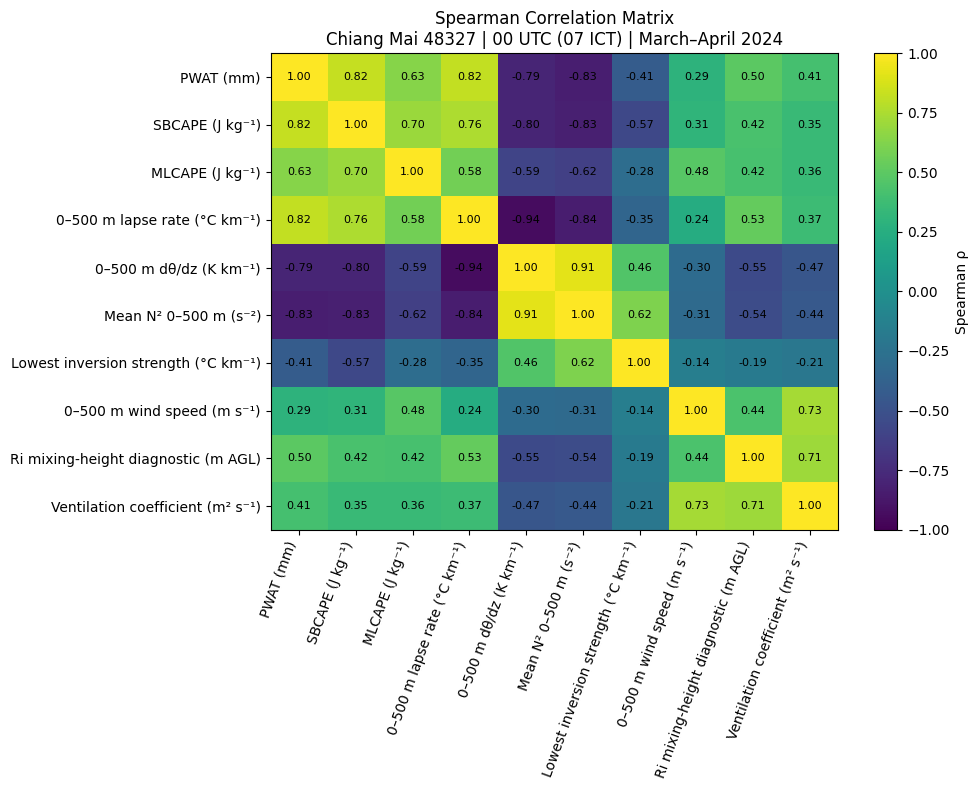

Saved: /content/drive/MyDrive/Teaching_Sounding_AirQuality/04_figures/05_Spearman_correlation_matrix.png


In [18]:
# CELL 18 — Spearman correlation heatmap with matplotlib
fig, ax = plt.subplots(
    figsize=(10, 8)
)

matrix = (
    rho_matrix
    .astype(float)
    .to_numpy()
)

im = ax.imshow(
    matrix,
    vmin=-1,
    vmax=1,
    aspect="auto"
)

ax.set_xticks(
    np.arange(
        len(corr_vars)
    )
)

ax.set_yticks(
    np.arange(
        len(corr_vars)
    )
)

short_labels = [
    VARIABLE_LABELS.get(
        var,
        var
    )
    for var in corr_vars
]

ax.set_xticklabels(
    short_labels,
    rotation=70,
    ha="right"
)

ax.set_yticklabels(
    short_labels
)

for i in range(
    len(corr_vars)
):

    for j in range(
        len(corr_vars)
    ):

        value = matrix[
            i,
            j
        ]

        if np.isfinite(
            value
        ):
            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=8
            )

cbar = fig.colorbar(
    im,
    ax=ax
)

cbar.set_label(
    "Spearman ρ"
)

ax.set_title(
    "Spearman Correlation Matrix\n"
    "Chiang Mai 48327 | 00 UTC (07 ICT) | March–April 2024"
)

fig.tight_layout()

CORR_FIG = (
    FIG_DIR
    / "05_Spearman_correlation_matrix.png"
)

fig.savefig(
    CORR_FIG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    CORR_FIG
)

# 5.14 เลือกคู่ตัวแปรเพื่อดู Scatterplot

ตัวอย่างที่น่าสนใจ:

\[
Mixing\ Height
\leftrightarrow
Ventilation\ Coefficient
\]

และ

\[
\theta\ gradient
\leftrightarrow
Mixing\ Height
\]

แต่ความสัมพันธ์แรกมีส่วนหนึ่งเป็น **mathematical coupling** เพราะ ventilation coefficient มี mixing height อยู่ในสูตรโดยตรง

นี่เป็นตัวอย่างสำคัญของการแยก:

- statistical association
- mathematical dependence
- physical causation

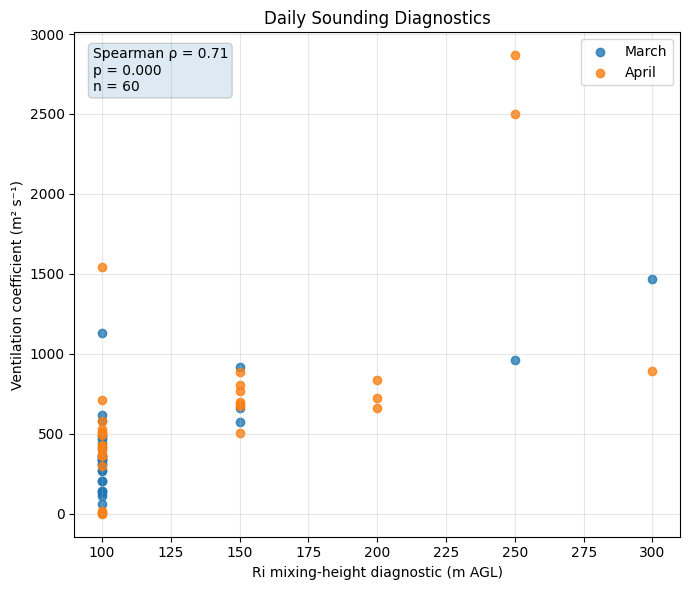

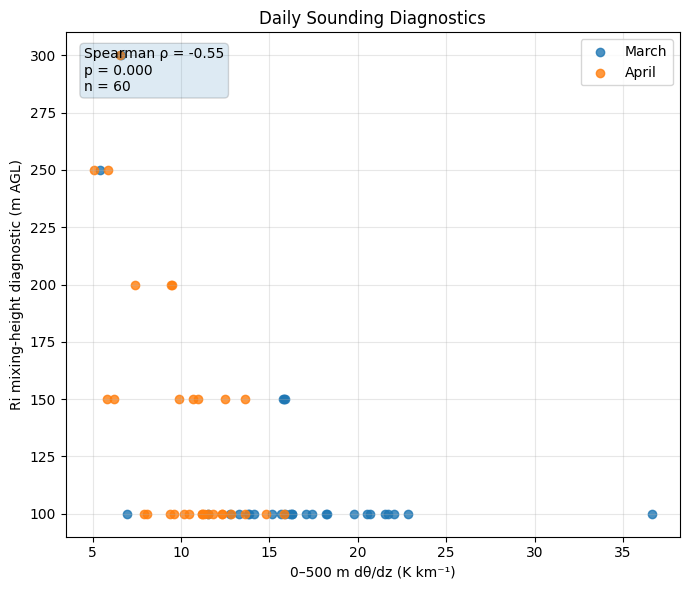

In [19]:
# CELL 19 — Example scatterplots
SCATTER_PAIRS = [
    (
        "mixing_height_Ri_m_AGL",
        "ventilation_coefficient_m2s"
    ),
    (
        "theta_grad_0_500_K_per_km",
        "mixing_height_Ri_m_AGL"
    )
]

for xvar, yvar in SCATTER_PAIRS:

    if (
        xvar not in daily.columns
        or yvar not in daily.columns
    ):
        continue

    pair = daily[
        [
            xvar,
            yvar,
            "month_name"
        ]
    ].dropna()

    fig, ax = plt.subplots(
        figsize=(7, 6)
    )

    for month_name in [
        "March",
        "April"
    ]:

        subset = pair[
            pair["month_name"]
            == month_name
        ]

        ax.scatter(
            subset[xvar],
            subset[yvar],
            label=month_name,
            alpha=0.8
        )

    if (
        len(pair) >= 3
        and pair[xvar].nunique() >= 2
        and pair[yvar].nunique() >= 2
    ):

        rho, pval = stats.spearmanr(
            pair[xvar],
            pair[yvar]
        )

        annotation = (
            f"Spearman ρ = {rho:.2f}\n"
            f"p = {pval:.3f}\n"
            f"n = {len(pair)}"
        )

        ax.text(
            0.03,
            0.97,
            annotation,
            transform=ax.transAxes,
            va="top",
            bbox={
                "boxstyle": "round",
                "alpha": 0.15
            }
        )

    ax.set_xlabel(
        VARIABLE_LABELS.get(
            xvar,
            xvar
        )
    )

    ax.set_ylabel(
        VARIABLE_LABELS.get(
            yvar,
            yvar
        )
    )

    ax.set_title(
        "Daily Sounding Diagnostics"
    )

    ax.grid(
        alpha=0.3
    )

    ax.legend()

    fig.tight_layout()

    path = (
        FIG_DIR
        / f"05_scatter_{xvar}_vs_{yvar}.png"
    )

    fig.savefig(
        path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

# 5.15 Temporal Autocorrelation

Hypothesis tests เช่น Welch's t-test และ Mann–Whitney U มักอาศัยแนวคิดว่า observations แต่ละตัวมีความเป็นอิสระกันในระดับหนึ่ง

แต่ atmospheric time series มักมี persistence:

> วันนี้อาจคล้ายเมื่อวานมากกว่าวันที่ห่างกันหลายสัปดาห์

เรียกว่า **temporal autocorrelation**

Lag-1 autocorrelation:

\[
r_1=
corr(X_t,X_{t-1})
\]

ถ้า \(r_1\) เป็นบวกสูง sample size ที่มี 61 วันอาจมี **effective information** น้อยกว่า 61 independent observations

In [20]:
# CELL 20 — Lag-1 autocorrelation
def lag1_autocorrelation(
    series
):
    x = pd.to_numeric(
        series,
        errors="coerce"
    )

    pair = pd.DataFrame({
        "current": x,
        "lag1": x.shift(1)
    }).dropna()

    if (
        len(pair) < 3
        or pair["current"].nunique() < 2
        or pair["lag1"].nunique() < 2
    ):
        return np.nan

    return float(
        pair[
            "current"
        ]
        .corr(
            pair["lag1"]
        )
    )


autocorr_rows = []

for var in ANALYSIS_VARS:

    r1 = lag1_autocorrelation(
        daily[var]
    )

    n_valid = int(
        daily[var]
        .notna()
        .sum()
    )

    # Simple AR(1)-style effective sample-size approximation.
    if (
        np.isfinite(r1)
        and (1 + r1) != 0
    ):

        n_eff = (
            n_valid
            * (1 - r1)
            / (1 + r1)
        )

        # Bound for teaching/reporting convenience.
        n_eff = float(
            np.clip(
                n_eff,
                1,
                n_valid
            )
        )

    else:

        n_eff = np.nan

    autocorr_rows.append({
        "variable": var,
        "label": VARIABLE_LABELS.get(var, var),
        "n_valid": n_valid,
        "lag1_autocorrelation": r1,
        "AR1_approx_effective_n": n_eff
    })


autocorrelation_table = pd.DataFrame(
    autocorr_rows
)

display(
    autocorrelation_table
)

,variable,label,n_valid,lag1_autocorrelation,AR1_approx_effective_n
0,SBCAPE_Jkg,SBCAPE (J kg⁻¹),61,0.579176,16.255467
1,SBCIN_Jkg,SBCIN (J kg⁻¹),61,0.463568,22.357949
2,MLCAPE_Jkg,MLCAPE (J kg⁻¹),61,0.197093,40.913586
3,PWAT_mm,PWAT (mm),61,0.769698,7.938297
4,lapse_0_500_C_per_km,0–500 m lapse rate (°C km⁻¹),61,0.457113,22.727184
5,theta_grad_0_500_K_per_km,0–500 m dθ/dz (K km⁻¹),61,0.554962,17.458495
6,N2_mean_0_500_s-2,Mean N² 0–500 m (s⁻²),61,0.743077,8.991184
7,lowest_inv_strength_C_per_km,Lowest inversion strength (°C km⁻¹),50,0.090286,41.719039
8,wind_0_500_speed_ms,0–500 m wind speed (m s⁻¹),61,0.105841,49.323317
9,mixing_height_Ri_m_AGL,Ri mixing-height diagnostic (m AGL),60,0.232520,37.361478


## Effective sample size เป็นเพียง approximation

สูตรประมาณสำหรับ AR(1):

\[
n_{eff}
\approx
n
\frac{1-r_1}{1+r_1}
\]

ใช้เพื่อแสดงแนวคิดว่า serial dependence ลด independent information

แต่สูตรนี้มีข้อจำกัด:

- สมมติ dependence คล้าย AR(1)
- ไม่ได้แทน block bootstrap หรือ time-series model
- \(r_1\) ที่ประเมินจาก sample สั้นมี uncertainty
- daily atmospheric process อาจมี nonstationarity

ดังนั้น Notebook นี้ **ไม่แก้ p-value ด้วยสูตรนี้โดยตรง**

จุดประสงค์คือให้นิสิตเข้าใจว่า \(n=61\) observations ไม่จำเป็นต้องเท่ากับ 61 independent pieces of information

# 5.16 ACF แบบง่าย

Autocorrelation Function:

\[
ACF(k)=corr(X_t,X_{t-k})
\]

เราจะดู lag 1–10 วัน เพื่อดูว่าความสัมพันธ์ลดลงเร็วหรือช้าเพียงใด

,lag,acf,n_pairs
0,0,1.000000,60
1,1,0.087973,59
2,2,-0.109268,58
3,3,0.057901,57
4,4,0.181152,56
5,5,-0.067352,55
6,6,0.047292,54
7,7,-0.075263,53
8,8,-0.016691,52
9,9,-0.044291,51


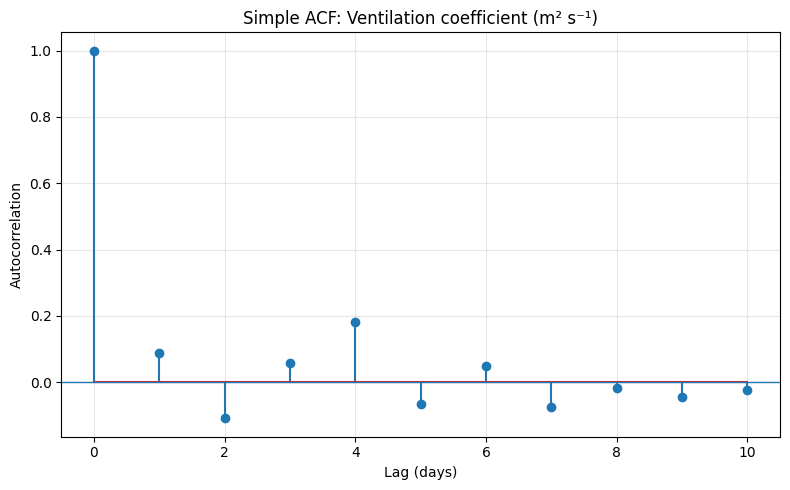

In [21]:
# CELL 21 — Simple ACF function
def simple_acf(
    series,
    max_lag=10
):
    x = pd.to_numeric(
        series,
        errors="coerce"
    )

    rows = []

    for lag in range(
        0,
        max_lag + 1
    ):

        if lag == 0:

            rows.append({
                "lag": 0,
                "acf": 1.0,
                "n_pairs": int(
                    x.notna().sum()
                )
            })

            continue

        pair = pd.DataFrame({
            "current": x,
            "lagged": x.shift(lag)
        }).dropna()

        if (
            len(pair) >= 3
            and pair["current"].nunique() >= 2
            and pair["lagged"].nunique() >= 2
        ):

            acf_value = pair[
                "current"
            ].corr(
                pair["lagged"]
            )

        else:

            acf_value = np.nan

        rows.append({
            "lag": lag,
            "acf": acf_value,
            "n_pairs": len(pair)
        })

    return pd.DataFrame(
        rows
    )


ACF_VAR = (
    "ventilation_coefficient_m2s"
    if "ventilation_coefficient_m2s" in daily.columns
    else ANALYSIS_VARS[0]
)

acf_table = simple_acf(
    daily[ACF_VAR],
    max_lag=10
)

display(
    acf_table
)

fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.stem(
    acf_table["lag"],
    acf_table["acf"]
)

ax.axhline(
    0,
    linewidth=1
)

ax.set_xlabel(
    "Lag (days)"
)

ax.set_ylabel(
    "Autocorrelation"
)

ax.set_title(
    f"Simple ACF: {VARIABLE_LABELS.get(ACF_VAR, ACF_VAR)}"
)

ax.grid(
    alpha=0.3
)

fig.tight_layout()

ACF_FIG = (
    FIG_DIR
    / f"05_ACF_{ACF_VAR}.png"
)

fig.savefig(
    ACF_FIG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 5.17 วิธีตีความผล March vs April อย่างเป็นระบบ

ควรอ่านผลตามลำดับ:

### ขั้นที่ 1 — ดู distribution

- boxplot
- ECDF
- skewness
- outliers

### ขั้นที่ 2 — ดู descriptive difference

- mean difference
- median difference
- IQR

### ขั้นที่ 3 — ดู effect size

ถามว่า difference มีขนาดมากน้อยเพียงใด

### ขั้นที่ 4 — ดู p-value

ใช้เป็นหลักฐานประกอบ ไม่ใช่คำตอบเพียงอย่างเดียว

### ขั้นที่ 5 — ดู temporal autocorrelation

หาก persistence สูง independent-sample inference อาจ optimistic เกินไป

### ขั้นที่ 6 — กลับไปหา atmospheric physics

ถามว่า difference ที่พบสามารถอธิบายด้วย thermodynamic/stability processes หรือไม่

In [22]:
# CELL 22 — Compact interpretation table
interpretation_table = tests_month[
    [
        "variable",
        "label",
        "n_March",
        "n_April",
        "mean_difference_April_minus_March",
        "median_difference_April_minus_March",
        "Cohens_d_April_minus_March",
        "Welch_p",
        "Welch_p_FDR",
        "MannWhitney_p",
        "MW_p_FDR"
    ]
].copy()

interpretation_table = interpretation_table.merge(
    autocorrelation_table[
        [
            "variable",
            "lag1_autocorrelation",
            "AR1_approx_effective_n"
        ]
    ],
    on="variable",
    how="left"
)

display(
    interpretation_table
)

,variable,label,n_March,n_April,mean_difference_April_minus_March,median_difference_April_minus_March,Cohens_d_April_minus_March,Welch_p,Welch_p_FDR,MannWhitney_p,MW_p_FDR,lag1_autocorrelation,AR1_approx_effective_n
0,SBCAPE_Jkg,SBCAPE (J kg⁻¹),31,30,1195.239404,1160.592533,1.730180,9.406665e-08,5.173666e-07,2.478909e-09,2.726800e-08,0.579176,16.255467
1,SBCIN_Jkg,SBCIN (J kg⁻¹),31,30,-113.910007,-225.298900,-0.681941,9.908093e-03,1.362363e-02,2.605658e-03,3.582780e-03,0.463568,22.357949
2,MLCAPE_Jkg,MLCAPE (J kg⁻¹),31,30,205.972328,38.034804,0.868483,2.326701e-03,3.656245e-03,5.261523e-04,8.268108e-04,0.197093,40.913586
3,PWAT_mm,PWAT (mm),31,30,9.793346,10.271687,2.075443,4.669956e-11,5.136952e-10,2.268475e-08,1.247661e-07,0.769698,7.938297
4,lapse_0_500_C_per_km,0–500 m lapse rate (°C km⁻¹),31,30,5.249520,4.798897,1.218521,1.797710e-05,3.954962e-05,1.207326e-06,3.301371e-06,0.457113,22.727184
5,theta_grad_0_500_K_per_km,0–500 m dθ/dz (K km⁻¹),31,30,-6.369128,-5.612146,-1.420661,1.311686e-06,4.809514e-06,2.504258e-07,9.182278e-07,0.554962,17.458495
6,N2_mean_0_500_s-2,Mean N² 0–500 m (s⁻²),31,30,-0.000193,-0.000196,-1.373559,2.429254e-06,6.680449e-06,1.500623e-06,3.301371e-06,0.743077,8.991184
7,lowest_inv_strength_C_per_km,Lowest inversion strength (°C km⁻¹),29,21,-6.307928,-5.616328,-1.067210,2.719100e-04,4.985016e-04,4.673884e-04,8.268108e-04,0.090286,41.719039
8,wind_0_500_speed_ms,0–500 m wind speed (m s⁻¹),31,30,0.581162,0.185292,0.335031,1.976930e-01,1.976930e-01,2.697633e-01,2.697633e-01,0.105841,49.323317
9,mixing_height_Ri_m_AGL,Ri mixing-height diagnostic (m AGL),30,30,21.666667,0.000000,0.425932,1.045970e-01,1.150568e-01,3.076465e-02,3.384112e-02,0.232520,37.361478


# 5.18 Save Analysis Products

Notebook จะบันทึก:

1. merged 61-day daily dataset
2. descriptive statistics
3. monthly descriptive statistics
4. March–April hypothesis tests
5. Spearman correlation matrix
6. Spearman p-value matrix
7. pairwise sample-size matrix
8. temporal autocorrelation table
9. compact interpretation table

ไฟล์เหล่านี้สามารถใช้ต่อใน mini research project ที่เพิ่ม PM₂.₅ ได้

In [23]:
# CELL 23 — Save all statistical outputs
MERGED_FILE = (
    OUTPUT_DIR
    / "05_merged_daily_sounding_diagnostics_48327_MarApr2024.csv"
)

DESC_ALL_FILE = (
    OUTPUT_DIR
    / "05_descriptive_statistics_all.csv"
)

DESC_MONTH_FILE = (
    OUTPUT_DIR
    / "05_descriptive_statistics_March_April.csv"
)

TEST_FILE = (
    OUTPUT_DIR
    / "05_March_vs_April_statistical_tests.csv"
)

RHO_FILE = (
    OUTPUT_DIR
    / "05_Spearman_rho_matrix.csv"
)

PVAL_FILE = (
    OUTPUT_DIR
    / "05_Spearman_pvalue_matrix.csv"
)

NPAIR_FILE = (
    OUTPUT_DIR
    / "05_Spearman_pairwise_n_matrix.csv"
)

AUTOCORR_FILE = (
    OUTPUT_DIR
    / "05_temporal_autocorrelation_summary.csv"
)

INTERPRET_FILE = (
    OUTPUT_DIR
    / "05_statistical_interpretation_table.csv"
)

daily.to_csv(
    MERGED_FILE,
    index=False
)

descriptive_all.to_csv(
    DESC_ALL_FILE,
    index=False
)

descriptive_monthly.to_csv(
    DESC_MONTH_FILE,
    index=False
)

tests_month.to_csv(
    TEST_FILE,
    index=False
)

rho_matrix.to_csv(
    RHO_FILE
)

p_matrix.to_csv(
    PVAL_FILE
)

n_matrix.to_csv(
    NPAIR_FILE
)

autocorrelation_table.to_csv(
    AUTOCORR_FILE,
    index=False
)

interpretation_table.to_csv(
    INTERPRET_FILE,
    index=False
)

print("Saved statistical outputs:")

for path in [
    MERGED_FILE,
    DESC_ALL_FILE,
    DESC_MONTH_FILE,
    TEST_FILE,
    RHO_FILE,
    PVAL_FILE,
    NPAIR_FILE,
    AUTOCORR_FILE,
    INTERPRET_FILE
]:
    print(
        " -",
        path
    )

Saved statistical outputs:
 - /content/drive/MyDrive/Teaching_Sounding_AirQuality/03_output/05_merged_daily_sounding_diagnostics_48327_MarApr2024.csv
 - /content/drive/MyDrive/Teaching_Sounding_AirQuality/03_output/05_descriptive_statistics_all.csv
 - /content/drive/MyDrive/Teaching_Sounding_AirQuality/03_output/05_descriptive_statistics_March_April.csv
 - /content/drive/MyDrive/Teaching_Sounding_AirQuality/03_output/05_March_vs_April_statistical_tests.csv
 - /content/drive/MyDrive/Teaching_Sounding_AirQuality/03_output/05_Spearman_rho_matrix.csv
 - /content/drive/MyDrive/Teaching_Sounding_AirQuality/03_output/05_Spearman_pvalue_matrix.csv
 - /content/drive/MyDrive/Teaching_Sounding_AirQuality/03_output/05_Spearman_pairwise_n_matrix.csv
 - /content/drive/MyDrive/Teaching_Sounding_AirQuality/03_output/05_temporal_autocorrelation_summary.csv
 - /content/drive/MyDrive/Teaching_Sounding_AirQuality/03_output/05_statistical_interpretation_table.csv


# 5.19 แบบฝึกหัด

## Exercise 1 — Mean vs Median

เลือกตัวแปร 3 ตัว แล้วเปรียบเทียบ:

- mean
- median
- skewness

ตอบว่าตัวแปรใดมี distribution เบ้ชัดที่สุด และควรใช้ค่ากลางใดในการรายงาน

---

## Exercise 2 — March vs April

เลือกตัวแปร 3 ตัว แล้วรายงาน:

1. March median [IQR]
2. April median [IQR]
3. Welch p-value
4. Mann–Whitney p-value
5. effect size
6. FDR-adjusted p-value
7. interpretation ทางอุตุนิยมวิทยา

---

## Exercise 3 — Rolling Mean

เปรียบเทียบ raw data, 3-day rolling mean และ 7-day rolling mean

ตอบว่า:

> pattern ใดหายไปเมื่อ smoothing มากขึ้น?

---

## Exercise 4 — Correlation

เลือกคู่ตัวแปรที่ \(|\rho_s|\) สูงอย่างน้อย 2 คู่

อภิปรายว่า correlation นั้นเกิดจาก:

- physical relationship?
- mathematical coupling?
- shared atmospheric forcing?
- หรือยังไม่สามารถสรุปได้?

---

## Exercise 5 — Statistical significance

หาตัวแปรที่:

- p < 0.05
- แต่ effect size เล็ก

แล้วอธิบายว่าทำไม “statistically significant” ไม่จำเป็นต้องหมายถึง “physically important”

---

## Exercise 6 — Temporal Autocorrelation

เลือกตัวแปรที่ lag-1 autocorrelation สูง

ตอบว่า:

1. persistence ทางบรรยากาศอาจเกิดจากอะไร?
2. เพราะเหตุใด independent-sample test จึงอาจมีข้อจำกัด?
3. วิธีขั้นสูงใดอาจใช้แทน เช่น block bootstrap หรือ time-series model?

---

# สรุป Notebook 05

นิสิตควรเข้าใจว่า:

1. descriptive statistics ต้องเลือกให้เหมาะกับ distribution
2. median และ IQR มีประโยชน์มากสำหรับข้อมูลที่ skewed
3. time series ต้องดูทั้ง raw variability และ multi-day persistence
4. boxplot และ ECDF ช่วยเปรียบเทียบ distribution
5. Welch's t-test เน้น mean difference
6. Mann–Whitney U เป็น rank-based comparison
7. p-value ไม่บอก effect magnitude หรือ causality
8. multiple testing ควรถูกพิจารณาเมื่อทดสอบหลายตัวแปร
9. Spearman correlation วัด monotonic association
10. correlation matrix เป็น exploratory tool
11. temporal autocorrelation ลดความเป็นอิสระของ daily observations
12. statistical results ต้องตีความร่วมกับ atmospheric physics

---

# ขั้นต่อยอดเป็น Mini Research Project

จากไฟล์

```text
05_merged_daily_sounding_diagnostics_48327_MarApr2024.csv
```

สามารถเพิ่มข้อมูล PM₂.₅ จาก Air4Thai แล้วศึกษา:

\[
PM_{2.5}
\leftrightarrow
Mixing\ Height
\]

\[
PM_{2.5}
\leftrightarrow
Inversion\ Strength
\]

\[
PM_{2.5}
\leftrightarrow
Ventilation\ Coefficient
\]

\[
PM_{2.5}
\leftrightarrow
PWAT,\ RH,\ Wind
\]

แต่การวิเคราะห์ PM₂.₅ ควรรวม source/emission information และ regional transport ด้วย เพื่อหลีกเลี่ยงการตีความ meteorology เป็น causal explanation เพียงอย่างเดียว